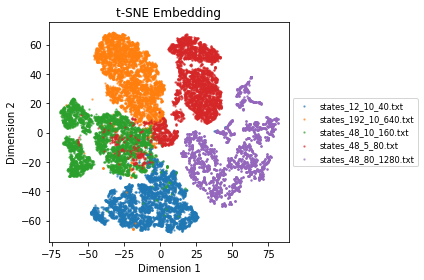

In [9]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import os
import matplotlib.pyplot as plt

# Store all vectors for global normalization
directory = 'state_collection'
all_vectors = []
file_labels = []

# Read all state files and store the vectors
for filename in os.listdir(directory):
    if filename.endswith('.txt'):
        file_path = os.path.join(directory, filename)
        with open(file_path, 'r') as f:
            data = f.read()
            vectors_str = data.split('[')[1:]
            for vector_str in vectors_str:
                vector = np.fromstring(vector_str.split(']')[0], sep=' ')
                if np.count_nonzero(vector) != 0:  # Ignore empty vectors
                    all_vectors.append(vector)
                    file_labels.append(filename)  # Keep track of which file each vector belongs to

# Normalize across all environments
all_vectors = np.array(all_vectors)
scaler = StandardScaler()
all_vectors_normalized = scaler.fit_transform(all_vectors)

# Chose perplexity of 50 within the recommended range of 5-50
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
embeddings = tsne.fit_transform(all_vectors_normalized)

# Plot the embeddings with different colors per environment
fig, ax = plt.subplots()
unique_files = np.unique(file_labels)
for i, filename in enumerate(unique_files):
    indices = [idx for idx, label in enumerate(file_labels) if label == filename]
    ax.scatter(embeddings[indices, 0], embeddings[indices, 1], label=filename, s=2, alpha=0.5)

# Set labels and title
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('t-SNE Embedding')

# Add legend outside of the plot
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')

# Show the plot
plt.tight_layout()
plt.show()